# **Data Preparation & Validation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================

file_path = '/content/Study Case for Univ Airlangga 2026 _Actuarial AXA .xlsx'

df_prem = pd.read_excel(file_path, sheet_name='Raw Premium')
df_claim = pd.read_excel(file_path, sheet_name='Raw Claim')

BadZipFile: File is not a zip file

In [ ]:
# =========================
# DATA UNDERSTANDING
# =========================

print("PREMIUM SHAPE :", df_prem.shape)
print("CLAIM SHAPE   :", df_claim.shape)

print("\n=== MISSING VALUES PREMIUM ===")
print(df_prem.isnull().sum())

print("\n=== MISSING VALUES CLAIM ===")
print(df_claim.isnull().sum())

# =========================
# DATE CONVERSION
# =========================

date_cols_prem = ['DT_INC', 'DT_END']
date_cols_claim = ['DT_CLM']

for col in date_cols_prem:
    df_prem[col] = pd.to_datetime(
        df_prem[col],
        errors='coerce')

for col in date_cols_claim:
    df_claim[col] = pd.to_datetime(
        df_claim[col],
        errors='coerce')

# =========================
# UNDERWRITING YEAR
# =========================

df_prem['UW_YEAR'] = df_prem['DT_INC'].dt.year
df_claim['CLM_YEAR'] = df_claim['DT_CLM'].dt.year

# =========================
# TENURE POLICY
# =========================

df_prem['TENURE_DAYS'] = (df_prem['DT_END'] - df_prem['DT_INC']).dt.days

# =========================
# EXACT DUPLICATES
# =========================

print("\nEXACT DUPLICATE PREMIUM :", df_prem.duplicated().sum())
print("EXACT DUPLICATE CLAIM   :", df_claim.duplicated().sum())

# =========================
# NEGATIVE VALUES CHECK
# =========================

premium_cols = [
    'GWP_IDR',
    'RWP_IDR',
    'GWC_IDR',
    'RWC_IDR',
    'SUM_INSURED']

claim_cols = [
    'GRS_ST_IDR',
    'RI_ST_IDR',
    'GRS_OS_IDR',
    'RI_OS_IDR']

print("\n=== NEGATIVE VALUES PREMIUM ===")
for col in premium_cols:
    print(col, (df_prem[col] < 0).sum())

print("\n=== NEGATIVE VALUES CLAIM ===")
for col in claim_cols:
    print(col, (df_claim[col] < 0).sum())

# =========================
# UNIQUE SEGMENTS
# =========================

segment_cols = [
    'COB',
    'BRANCH_',
    'CHANNEL_',
    'PRODUCT_NAME']

print("\n=== UNIQUE SEGMENTS ===")
for col in segment_cols:
    print(f"\n{col}")
    print(df_prem[col].nunique())

# =========================
# BASIC STATISTICS
# =========================

print("\n=== PREMIUM STATISTICS ===")

print(
    df_prem[
        premium_cols
    ].describe())

print("\n=== CLAIM STATISTICS ===")

print(
    df_claim[
        claim_cols
    ].describe())

# =========================
# TENURE DISTRIBUTION
# =========================

print("\n=== TENURE SUMMARY ===")
print(df_prem['TENURE_DAYS'].describe())

# **Portofolio Overview**

                Metric         Value
0  Total Gross Premium  2.510719e+12
1    Total Net Premium  1.964121e+12
2    Total Sum Insured  2.986545e+15
3       Total Policies  1.563010e+05

===== SUMMARY BY COB =====
            GWP_IDR   NET_PREMIUM   SUM_INSURED  POLICY_NO
COB                                                       
COB 9  7.624109e+11  4.669920e+11  7.365629e+14      46754
COB 6  4.206605e+11  4.151836e+11  1.354778e+15       4876
COB 7  3.429804e+11  3.426969e+11  2.128440e+13      41763
COB 4  3.192075e+11  2.629997e+11  5.559157e+14       1693
COB 8  2.515343e+11  2.514895e+11  7.185581e+13       2382


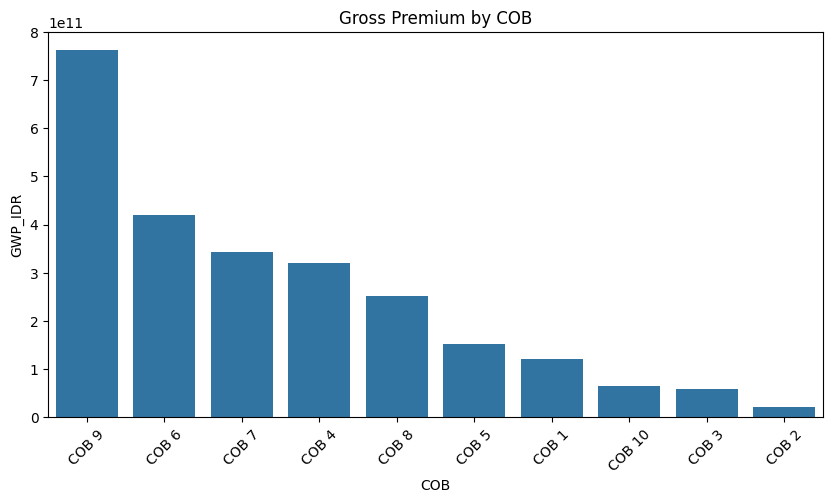


===== SUMMARY BY BRANCH_ =====
               GWP_IDR   NET_PREMIUM   SUM_INSURED  POLICY_NO
BRANCH_                                                      
BRANCH K  1.176841e+12  8.415608e+11  1.031903e+15      46405
BRANCH J  4.146388e+11  3.198664e+11  1.447252e+15      45817
BRANCH D  1.592619e+11  1.098779e+11  9.646030e+13      12709
BRANCH E  1.542209e+11  1.367521e+11  1.010242e+14      10557
BRANCH A  1.518248e+11  1.321832e+11  8.408534e+13      10566


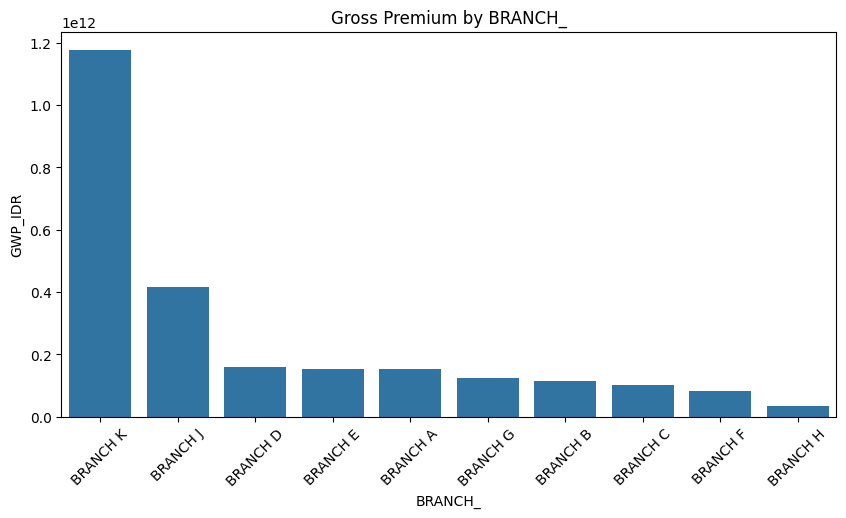


===== SUMMARY BY CHANNEL_ =====
                GWP_IDR   NET_PREMIUM   SUM_INSURED  POLICY_NO
CHANNEL_                                                      
CHANNEL D  7.576710e+11  7.121378e+11  4.202610e+14      61230
CHANNEL C  7.010222e+11  3.696118e+11  9.335389e+14       9303
CHANNEL B  4.881833e+11  4.836138e+11  1.253015e+14      37073
CHANNEL E  3.271361e+11  1.914889e+11  1.319732e+15       6453
CHANNEL A  2.367069e+11  2.072689e+11  1.877119e+14      42251


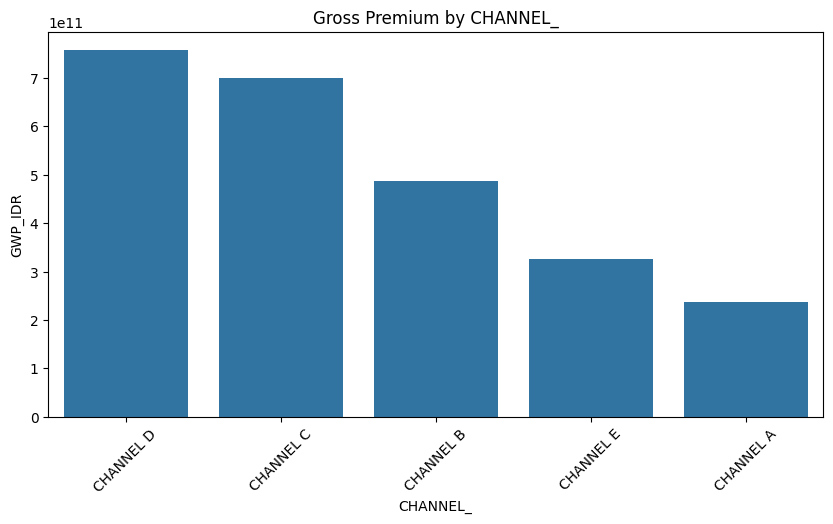

In [ ]:
# =========================
# STEP 2 - PORTFOLIO OVERVIEW
# =========================

# Net Premium
df_prem['NET_PREMIUM'] = (df_prem['GWP_IDR'] - df_prem['RWP_IDR'])

# Portfolio Summary
portfolio_summary = pd.DataFrame({
    'Metric': [
        'Total Gross Premium',
        'Total Net Premium',
        'Total Sum Insured',
        'Total Policies'],
    'Value': [
        df_prem['GWP_IDR'].sum(),
        df_prem['NET_PREMIUM'].sum(),
        df_prem['SUM_INSURED'].sum(),
        df_prem['POLICY_NO'].nunique()]})

print(portfolio_summary)

# =========================
# SEGMENT OVERVIEW
# =========================

segment_cols = ['COB', 'BRANCH_', 'CHANNEL_']

for seg in segment_cols:

    summary = (
        df_prem
        .groupby(seg)
        .agg({
            'GWP_IDR':'sum',
            'NET_PREMIUM':'sum',
            'SUM_INSURED':'sum',
            'POLICY_NO':'nunique' })
        .sort_values(by='GWP_IDR', ascending=False))

    print(f"\n===== SUMMARY BY {seg} =====")
    print(summary.head())

    # Visualization
    plt.figure(figsize=(10,5))

    sns.barplot(data=summary.reset_index(),
                x=seg,
                y='GWP_IDR')

    plt.title(f'Gross Premium by {seg}')
    plt.xticks(rotation=45)
    plt.show()

# **Exposure Concentration Analysis**

In [ ]:
# ==================================================
# STEP 3 - EXPOSURE CONCENTRATION ANALYSIS
# ==================================================

# Rate on Line per policy
df_prem['RATE_ON_LINE'] = (
    df_prem['GWP_IDR'] /
    df_prem['SUM_INSURED'])

# ==================================================
# AGGREGATE BY COB
# ==================================================

exposure_summary = (
    df_prem
    .groupby('COB')
    .agg(
        TOTAL_EXPOSURE = ('SUM_INSURED','sum'),
        TOTAL_PREMIUM = ('GWP_IDR','sum'),
        TOTAL_POLICIES = ('POLICY_NO','nunique')
    ).reset_index())

# ==================================================
# EXPOSURE SHARE
# ==================================================

exposure_summary['EXPOSURE_SHARE_%'] = (
    exposure_summary['TOTAL_EXPOSURE']
    /
    exposure_summary['TOTAL_EXPOSURE'].sum()
    * 100)

# ==================================================
# PREMIUM SHARE
# ==================================================

exposure_summary['PREMIUM_SHARE_%'] = (
    exposure_summary['TOTAL_PREMIUM']
    /
    exposure_summary['TOTAL_PREMIUM'].sum()
    * 100)

# ==================================================
# RATE ON LINE
# ==================================================

exposure_summary['RATE_ON_LINE'] = (
    exposure_summary['TOTAL_PREMIUM']
    /
    exposure_summary['TOTAL_EXPOSURE'])

# ==================================================
# GAP ANALYSIS
# ==================================================

exposure_summary['EXPOSURE_PREMIUM_GAP'] = (
    exposure_summary['EXPOSURE_SHARE_%']
    -
    exposure_summary['PREMIUM_SHARE_%'])

# Sort by exposure
exposure_summary = (
    exposure_summary
    .sort_values(
        by='TOTAL_EXPOSURE',
        ascending=False))

print(exposure_summary)
display(exposure_summary)

      COB  TOTAL_EXPOSURE  TOTAL_PREMIUM  TOTAL_POLICIES  EXPOSURE_SHARE_%  \
6   COB 6    1.354778e+15   4.206605e+11            4876         45.362712   
9   COB 9    7.365629e+14   7.624109e+11           46754         24.662704   
4   COB 4    5.559157e+14   3.192075e+11            1693         18.614003   
1  COB 10    1.055785e+14   6.489250e+10           52085          3.535136   
0   COB 1    9.131532e+13   1.196189e+11            4983          3.057557   
8   COB 8    7.185581e+13   2.515343e+11            2382          2.405984   
5   COB 5    2.516984e+13   1.510009e+11             909          0.842775   
3   COB 3    2.327878e+13   5.746793e+10             835          0.779455   
7   COB 7    2.128440e+13   3.429804e+11           41763          0.712676   
2   COB 2    8.063062e+11   2.094564e+10              21          0.026998   

   PREMIUM_SHARE_%  RATE_ON_LINE  EXPOSURE_PREMIUM_GAP  
6        16.754581      0.000311             28.608131  
9        30.366231      0.0

,COB,TOTAL_EXPOSURE,TOTAL_PREMIUM,TOTAL_POLICIES,EXPOSURE_SHARE_%,PREMIUM_SHARE_%,RATE_ON_LINE,EXPOSURE_PREMIUM_GAP
6,COB 6,1.354778e+15,4.206605e+11,4876,45.362712,16.754581,0.000311,28.608131
9,COB 9,7.365629e+14,7.624109e+11,46754,24.662704,30.366231,0.001035,-5.703527
4,COB 4,5.559157e+14,3.192075e+11,1693,18.614003,12.713788,0.000574,5.900215
1,COB 10,1.055785e+14,6.489250e+10,52085,3.535136,2.584618,0.000615,0.950519
0,COB 1,9.131532e+13,1.196189e+11,4983,3.057557,4.764328,0.001310,-1.706771
8,COB 8,7.185581e+13,2.515343e+11,2382,2.405984,10.018415,0.003501,-7.612431
5,COB 5,2.516984e+13,1.510009e+11,909,0.842775,6.014248,0.005999,-5.171474
3,COB 3,2.327878e+13,5.746793e+10,835,0.779455,2.288903,0.002469,-1.509448
7,COB 7,2.128440e+13,3.429804e+11,41763,0.712676,13.660641,0.016114,-12.947964
2,COB 2,8.063062e+11,2.094564e+10,21,0.026998,0.834248,0.025977,-0.807250


### **Visualisasi Exposure Share vs Premium Share**


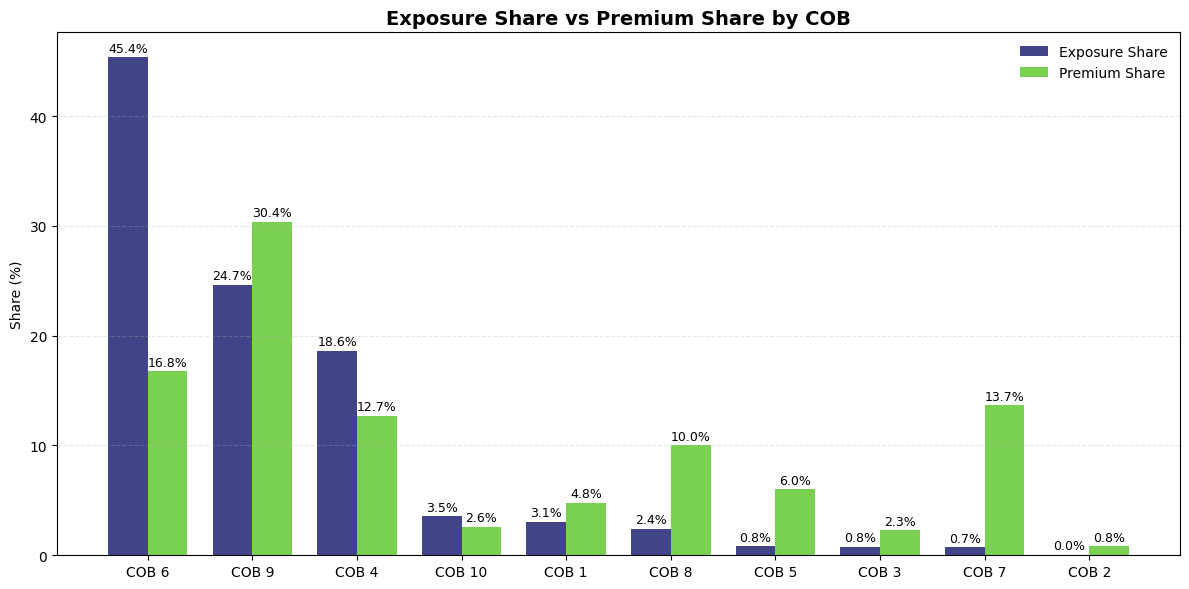

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort biar lebih enak dibaca
plot_df = exposure_summary.sort_values(
    by='EXPOSURE_SHARE_%',
    ascending=False
).reset_index(drop=True)

# Viridis colors
cmap = plt.cm.viridis
exposure_color = cmap(0.2)
premium_color = cmap(0.8)

plt.figure(figsize=(12,6))

x = np.arange(len(plot_df))
width = 0.38

bars1 = plt.bar(
    x - width/2,
    plot_df['EXPOSURE_SHARE_%'],
    width,
    color=exposure_color,
    label='Exposure Share'
)

bars2 = plt.bar(
    x + width/2,
    plot_df['PREMIUM_SHARE_%'],
    width,
    color=premium_color,
    label='Premium Share'
)

# Value labels
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontsize=9
    )

plt.xticks(
    x,
    plot_df['COB'],
    fontsize=10
)

plt.ylabel('Share (%)')
plt.title(
    'Exposure Share vs Premium Share by COB',
    fontsize=14,
    weight='bold'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### **Visualisasi Exposure Concentration**

/tmp/ipykernel_2802/3409348993.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


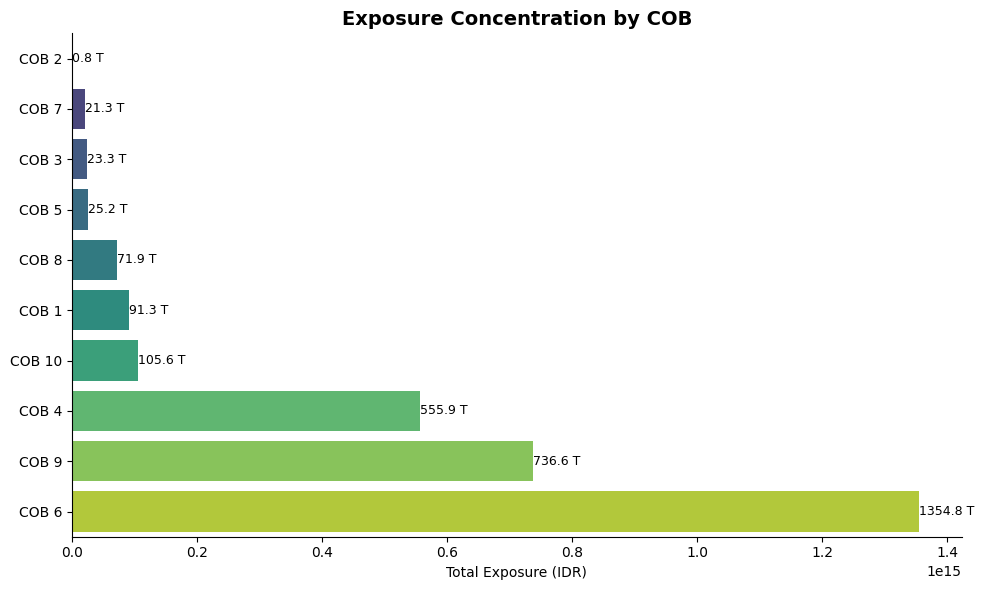

In [ ]:
plot_df = exposure_summary.sort_values(
    by='TOTAL_EXPOSURE',
    ascending=True
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_df,
    y='COB',
    x='TOTAL_EXPOSURE',
    palette='viridis'
)

for p in ax.patches:

    value = p.get_width()

    plt.annotate(
        f'{value/1e12:.1f} T',
        (
            value,
            p.get_y() + p.get_height()/2
        ),
        va='center',
        fontsize=9
    )

plt.title(
    'Exposure Concentration by COB',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Total Exposure (IDR)')
plt.ylabel('')

sns.despine()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2802/3397636992.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


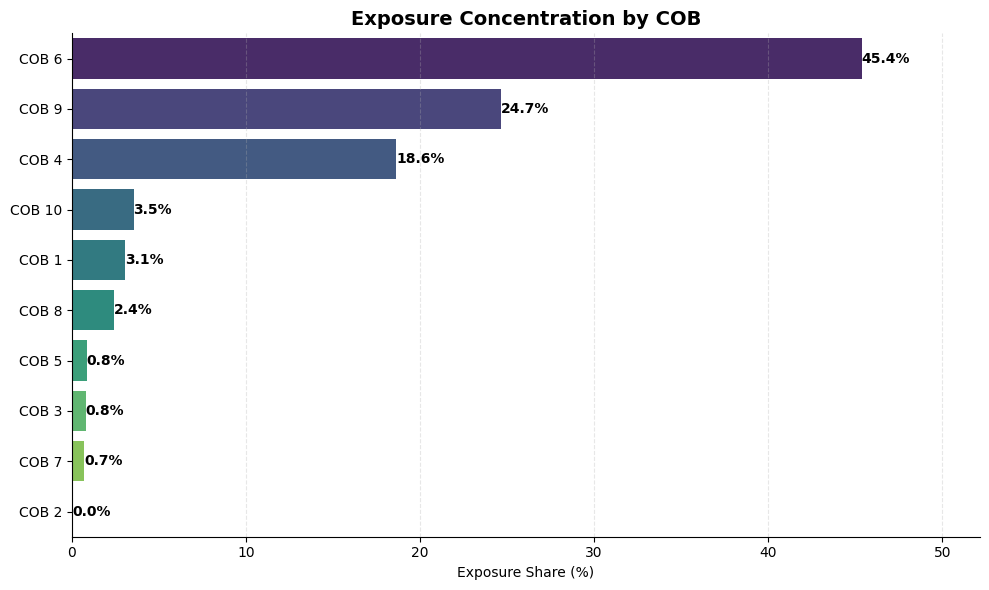

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Urutkan dari exposure terbesar
plot_df = exposure_summary.sort_values(
    by='EXPOSURE_SHARE_%',
    ascending=False
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_df,
    y='COB',
    x='EXPOSURE_SHARE_%',
    palette='viridis'
)

# Tambahkan label %
for p in ax.patches:

    value = p.get_width()

    plt.annotate(
        f'{value:.1f}%',
        (
            value,
            p.get_y() + p.get_height()/2
        ),
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Exposure Concentration by COB',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Exposure Share (%)')
plt.ylabel('')

plt.xlim(
    0,
    plot_df['EXPOSURE_SHARE_%'].max() * 1.15
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

sns.despine()

plt.tight_layout()

plt.show()

### **Visualisasi Rate on Line**

/tmp/ipykernel_2802/3889351094.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


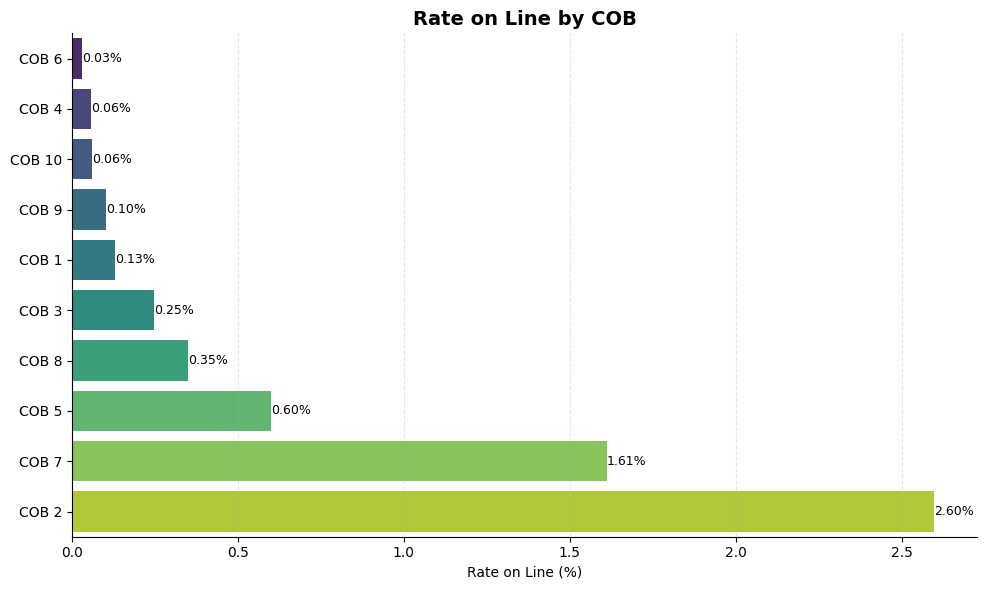

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort ascending supaya ranking lebih jelas
plot_df = exposure_summary.sort_values(
    by='RATE_ON_LINE',
    ascending=True
).copy()

# Convert ke persen
plot_df['RATE_ON_LINE_PCT'] = (
    plot_df['RATE_ON_LINE'] * 100
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_df,
    y='COB',
    x='RATE_ON_LINE_PCT',
    palette='viridis'
)

# Label nilai
for p in ax.patches:

    value = p.get_width()

    plt.annotate(
        f'{value:.2f}%',
        (
            value,
            p.get_y() + p.get_height()/2
        ),
        va='center',
        fontsize=9
    )

plt.title(
    'Rate on Line by COB',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Rate on Line (%)')
plt.ylabel('')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

### **Exposure Trend per UW Year** (Opsional)

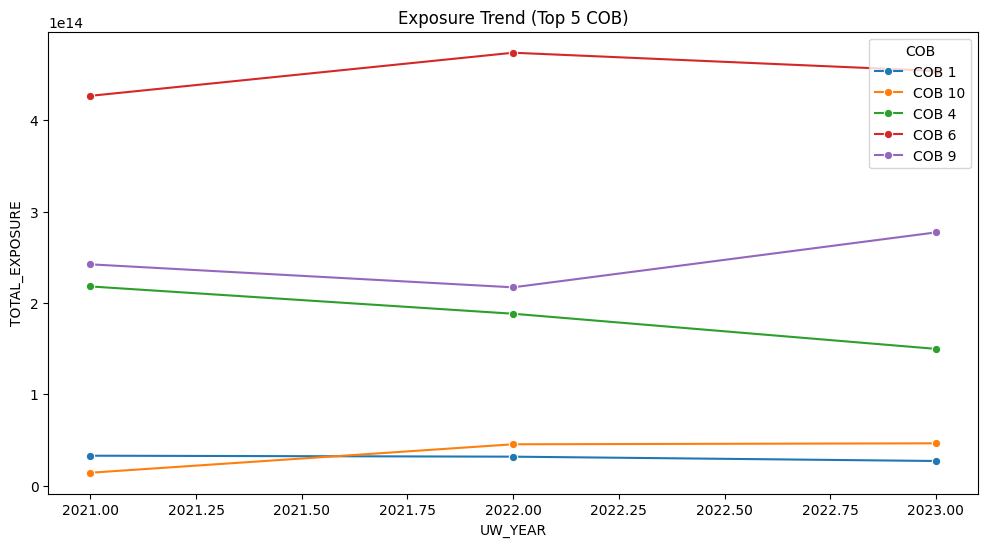

In [ ]:
top5_cob = (
    df_prem
    .groupby('COB')['SUM_INSURED']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

exposure_year_top = (
    df_prem[df_prem['COB'].isin(top5_cob)]
    .groupby(['UW_YEAR','COB'])
    .agg(
        TOTAL_EXPOSURE=('SUM_INSURED','sum')
    )
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=exposure_year_top,
    x='UW_YEAR',
    y='TOTAL_EXPOSURE',
    hue='COB',
    marker='o'
)

plt.title('Exposure Trend (Top 5 COB)')
plt.show()

### **Interpretasi**

**Temuan 1: Sebagian besar risiko perusahaan terkumpul pada tiga jenis bisnis utama**

Dari seluruh portofolio yang dianalisis, **hampir 89%** nilai pertanggungan perusahaan berasal dari tiga COB utama, yaitu **COB 6**, **COB 9**, dan **COB 4**.

**Artinya**

Perusahaan sangat bergantung pada ketiga segmen tersebut. **Jika terjadi peningkatan klaim atau kejadian besar** pada salah satu segmen tersebut, **dampaknya akan terasa** pada keseluruhan kinerja portofolio.

**Mengapa penting?**
Karena semakin terkonsentrasi risiko pada sedikit segmen, semakin besar potensi kerugian yang harus ditanggung perusahaan apabila terjadi kejadian yang tidak diharapkan.

**Temuan 2: COB 6 menanggung risiko paling besar, tetapi kontribusi pendapatannya relatif rendah**

COB 6 mencakup sekitar **45%** dari total **nilai pertanggungan**, namun hanya memberikan sekitar **17%** dari** total premi** yang diterima perusahaan.

**Artinya**

Perusahaan menanggung risiko yang sangat besar pada segmen ini, tetapi pendapatan yang diterima tidak sebanding dengan besarnya risiko tersebut.

**Hal yang perlu diperhatikan**

Segmen ini perlu dianalisis lebih lanjut pada tahap berikutnya untuk melihat apakah premi yang diterima sudah cukup untuk menutupi potensi klaim yang mungkin terjadi.

**Temuan 3: COB 9 menjadi salah satu kontributor pendapatan utama perusahaan**

COB 9 memiliki porsi premi yang lebih besar dibandingkan porsi risiko yang ditanggung.

**Artinya**

Setiap risiko yang ditanggung pada segmen ini menghasilkan pendapatan yang relatif lebih tinggi dibanding rata-rata segmen lainnya.

**Hal yang perlu diperhatikan**

Meskipun terlihat menjanjikan dari sisi pendapatan, perlu dilihat lebih lanjut apakah segmen ini juga memiliki tingkat klaim yang sehat.

**Temuan 4: COB 7 memiliki karakteristik menarik**

COB 7 hanya menyumbang kurang dari **1%** total nilai pertanggungan, tetapi menghasilkan sekitar **14%** dari total premi perusahaan.

**Artinya**

Perusahaan menerima pendapatan yang cukup besar meskipun risiko yang ditanggung relatif kecil.

**Potensi**

Jika tingkat klaim pada segmen ini rendah, maka COB 7 berpotensi menjadi salah satu segmen yang paling menguntungkan bagi perusahaan.

**Temuan 5: Risiko portofolio belum tersebar secara merata**

Beberapa COB memiliki porsi risiko yang sangat besar, sementara COB lainnya memiliki porsi yang jauh lebih kecil.

Artinya

Portofolio masih cukup bergantung pada beberapa segmen utama dan belum terdiversifikasi secara optimal.

Dampak

Ketika satu segmen utama mengalami masalah, misalnya lonjakan klaim atau kejadian besar, maka dampaknya terhadap kinerja perusahaan akan lebih besar dibanding jika risiko tersebar secara lebih merata.

# **Claim Analysis**


=== CLAIM FREQUENCY ===
COB
COB 2     1.333333
COB 4     0.761370
COB 7     0.317099
COB 6     0.302707
COB 3     0.219162
COB 8     0.133501
COB 5     0.088009
COB 9     0.060444
COB 1     0.054385
COB 10    0.007161
dtype: float64

=== CLAIM SEVERITY ===
COB
COB 5     7.253215e+08
COB 6     2.602098e+08
COB 4     2.260312e+08
COB 2     1.940786e+08
COB 8     1.189615e+08
COB 1     9.655605e+07
COB 9     4.624600e+07
COB 7     2.251447e+07
COB 10    1.573877e+07
COB 3     6.996799e+06
Name: GROSS_INCURRED, dtype: float64

=== LARGE CLAIM SUMMARY ===
COB
COB 6    2.652114e+11
COB 4    1.130857e+11
COB 9    6.043607e+10
COB 5    4.712929e+10
COB 8    3.745963e+10
COB 1    1.287260e+10
Name: GROSS_INCURRED, dtype: float64

=== CLAIM ANALYSIS SUMMARY ===
        CLAIM_FREQUENCY  CLAIM_SEVERITY  LARGE_CLAIM_AMOUNT
COB                                                        
COB 5          0.088009    7.253215e+08        4.712929e+10
COB 6          0.302707    2.602098e+08        2.652114e+

/tmp/ipykernel_2802/365623327.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


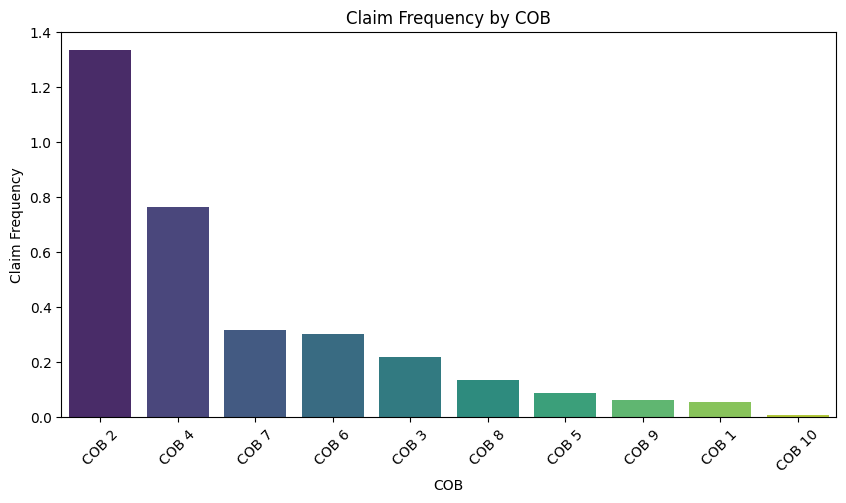

/tmp/ipykernel_2802/365623327.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


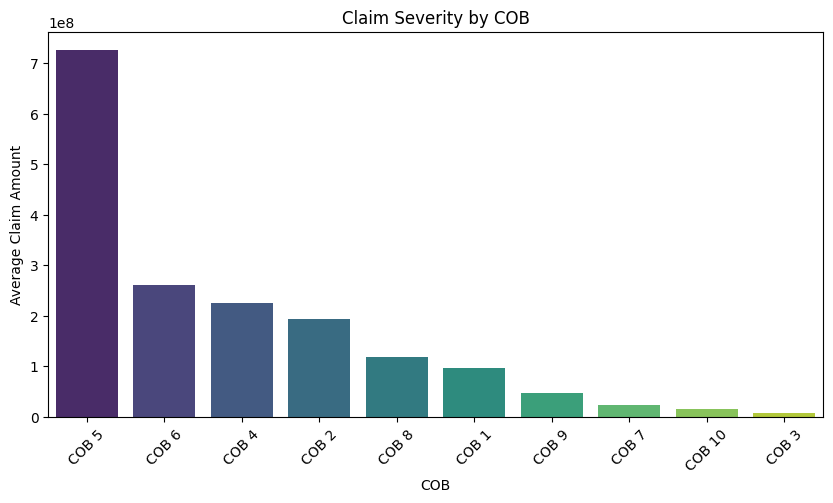

/tmp/ipykernel_2802/365623327.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


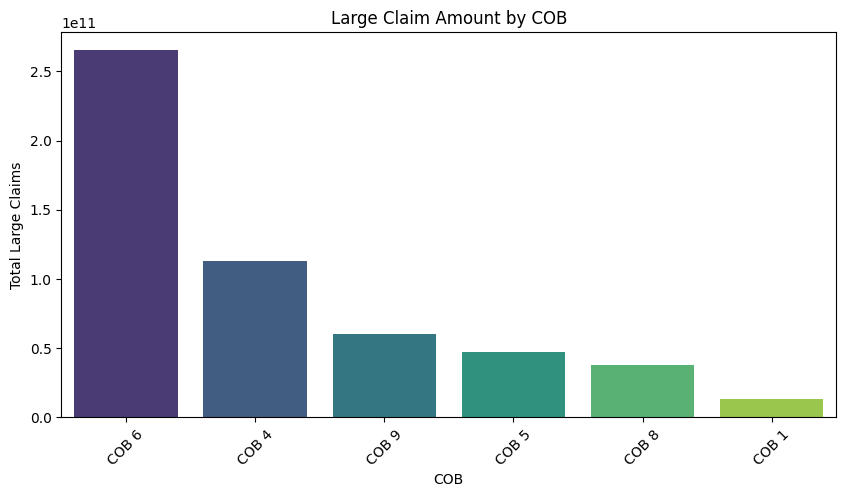

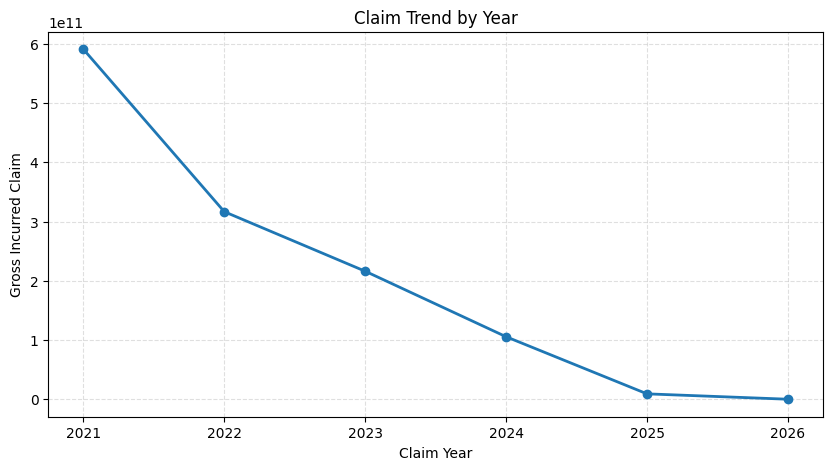

In [ ]:
# =========================
# STEP 4 - CLAIM ANALYSIS
# =========================

# =========================
# 1. CLAIM INCURRED
# =========================

# Gross Incurred Claim
df_claim['GROSS_INCURRED'] = (
    df_claim['GRS_ST_IDR'] +
    df_claim['GRS_OS_IDR']
)

# Net Incurred Claim
df_claim['NET_INCURRED'] = (
    df_claim['GROSS_INCURRED']
    -
    (
        df_claim['RI_ST_IDR']
        +
        df_claim['RI_OS_IDR']
    )
)

# =========================
# 2. CLAIM FREQUENCY
# =========================

claim_freq = (
    df_claim
    .groupby('COB')['CLM_REF']
    .nunique()
)

policy_count = (
    df_prem
    .groupby('COB')['POLICY_NO']
    .nunique()
)

claim_frequency = (
    claim_freq / policy_count
).sort_values(ascending=False)

print("\n=== CLAIM FREQUENCY ===")
print(claim_frequency)

# =========================
# 3. CLAIM SEVERITY
# =========================

severity = (
    df_claim
    .groupby('COB')['GROSS_INCURRED']
    .mean()
    .sort_values(ascending=False)
)

print("\n=== CLAIM SEVERITY ===")
print(severity)

# =========================
# 4. LARGE CLAIM ANALYSIS
# =========================

LARGE_THRESHOLD = 1_000_000_000

df_claim['LARGE_CLAIM_FLAG'] = (
    df_claim['GROSS_INCURRED']
    > LARGE_THRESHOLD
)

large_claim_summary = (
    df_claim[df_claim['LARGE_CLAIM_FLAG']]
    .groupby('COB')['GROSS_INCURRED']
    .sum()
    .sort_values(ascending=False)
)

print("\n=== LARGE CLAIM SUMMARY ===")
print(large_claim_summary)

# =========================
# 5. COMBINED CLAIM TABLE
# =========================

claim_analysis = pd.DataFrame({

    'CLAIM_FREQUENCY':
        claim_frequency,

    'CLAIM_SEVERITY':
        severity,

    'LARGE_CLAIM_AMOUNT':
        large_claim_summary

}).fillna(0)

claim_analysis = (
    claim_analysis
    .sort_values(
        by='CLAIM_SEVERITY',
        ascending=False
    )
)

print("\n=== CLAIM ANALYSIS SUMMARY ===")
print(claim_analysis)

# =========================
# 6. CLAIM FREQUENCY CHART
# =========================

plt.figure(figsize=(10,5))

sns.barplot(
    x=claim_frequency.index,
    y=claim_frequency.values,
    palette='viridis'
)

plt.title('Claim Frequency by COB')
plt.ylabel('Claim Frequency')
plt.xlabel('COB')

plt.xticks(rotation=45)

plt.show()

# =========================
# 7. CLAIM SEVERITY CHART
# =========================

plt.figure(figsize=(10,5))

sns.barplot(
    x=severity.index,
    y=severity.values,
    palette='viridis'
)

plt.title('Claim Severity by COB')
plt.ylabel('Average Claim Amount')
plt.xlabel('COB')

plt.xticks(rotation=45)

plt.show()

# =========================
# 8. LARGE CLAIM CHART
# =========================

plt.figure(figsize=(10,5))

sns.barplot(
    x=large_claim_summary.index,
    y=large_claim_summary.values,
    palette='viridis'
)

plt.title('Large Claim Amount by COB')
plt.ylabel('Total Large Claims')
plt.xlabel('COB')

plt.xticks(rotation=45)

plt.show()

# =========================
# 9. CLAIM TREND
# =========================

claim_trend = (
    df_claim
    .groupby('CLM_YEAR')['GROSS_INCURRED']
    .sum()
)

plt.figure(figsize=(10,5))

claim_trend.plot(
    marker='o',
    linewidth=2
)

plt.title('Claim Trend by Year')

plt.ylabel('Gross Incurred Claim')

plt.xlabel('Claim Year')

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.show()

# **Loss Ratio & Profitability Analysis**

In [ ]:
# ==========================================
# CLAIM METRICS
# ==========================================

df_claim['GROSS_INCURRED'] = (df_claim['GRS_ST_IDR'] + df_claim['GRS_OS_IDR'])

df_claim['RI_RECOVERY'] = (df_claim['RI_ST_IDR'] + df_claim['RI_OS_IDR'])

df_claim['NET_INCURRED'] = (df_claim['GROSS_INCURRED'] - df_claim['RI_RECOVERY'])

# ==========================================
# NET PREMIUM
# ==========================================

df_prem['NET_PREMIUM'] = (df_prem['GWP_IDR']- df_prem['RWP_IDR'])

### **Agregasi Loss Ratio per COB**

In [ ]:
# ==========================================
# STEP 5 - LOSS RATIO ANALYSIS
# ==========================================

# Claim Summary
claim_summary = (
    df_claim
    .groupby('COB')
    .agg(
        TOTAL_GROSS_CLAIM=('GROSS_INCURRED','sum'),
        TOTAL_NET_CLAIM=('NET_INCURRED','sum'))
    .reset_index())

# Premium Summary
premium_summary = (
    df_prem
    .groupby('COB')
    .agg(
        TOTAL_GWP=('GWP_IDR','sum'),
        TOTAL_RWP=('RWP_IDR','sum'),
        TOTAL_NET_PREMIUM=('NET_PREMIUM','sum')).reset_index())

# Merge
loss_ratio_df = pd.merge(
    premium_summary,
    claim_summary,
    on='COB',
    how='left')

loss_ratio_df.fillna(0, inplace=True)

# Gross LR
loss_ratio_df['GROSS_LOSS_RATIO'] = np.where(
    loss_ratio_df['TOTAL_GWP'] != 0,
    loss_ratio_df['TOTAL_GROSS_CLAIM']
    /
    loss_ratio_df['TOTAL_GWP'],
    0)

# Net LR
loss_ratio_df['NET_LOSS_RATIO'] = np.where(
    loss_ratio_df['TOTAL_NET_PREMIUM'] != 0,
    loss_ratio_df['TOTAL_NET_CLAIM']
    /
    loss_ratio_df['TOTAL_NET_PREMIUM'],
    0)

# Ranking
loss_ratio_df = (
    loss_ratio_df
    .sort_values(
        by='GROSS_LOSS_RATIO',
        ascending=False))

display(loss_ratio_df)

,COB,TOTAL_GWP,TOTAL_RWP,TOTAL_NET_PREMIUM,TOTAL_GROSS_CLAIM,TOTAL_NET_CLAIM,GROSS_LOSS_RATIO,NET_LOSS_RATIO
6,COB 6,4.206605e+11,5.476914e+09,4.151836e+11,3.840697e+11,3.836386e+11,0.913016,0.924022
4,COB 4,3.192075e+11,5.620782e+10,2.629997e+11,2.913542e+11,2.802180e+11,0.912742,1.065469
7,COB 7,3.429804e+11,2.834829e+08,3.426969e+11,2.981591e+11,2.981295e+11,0.869318,0.869951
5,COB 5,1.510009e+11,7.631139e+10,7.468951e+10,5.802572e+10,3.704782e+10,0.384274,0.496024
2,COB 2,2.094564e+10,5.180234e+04,2.094558e+10,5.434200e+09,5.434200e+09,0.259443,0.259444
0,COB 1,1.196189e+11,6.993509e+10,4.968382e+10,2.616669e+10,1.278392e+10,0.218750,0.257305
9,COB 9,7.624109e+11,2.954189e+11,4.669920e+11,1.306912e+11,8.792284e+10,0.171418,0.188275
8,COB 8,2.515343e+11,4.482585e+07,2.514895e+11,3.782976e+10,3.782976e+10,0.150396,0.150423
1,COB 10,6.489250e+10,0.000000e+00,6.489250e+10,5.870562e+09,5.870562e+09,0.090466,0.090466
3,COB 3,5.746793e+10,4.291977e+10,1.454815e+10,1.280414e+09,8.779565e+08,0.022281,0.060348


### **Visualisasi Gross vs Net Loss Ratio**

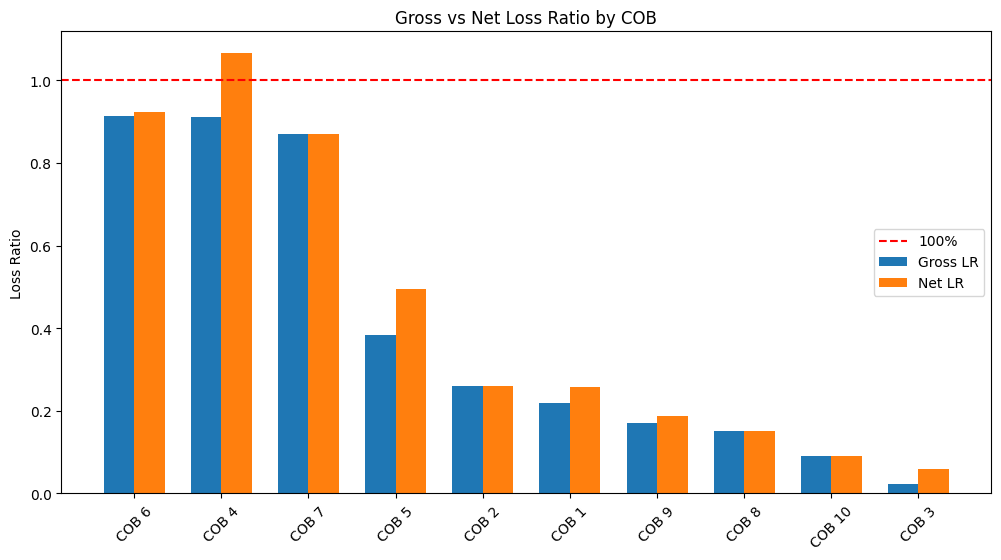

In [ ]:
plt.figure(figsize=(12,6))
x = np.arange(len(loss_ratio_df))
width = 0.35

plt.bar(
    x - width/2,
    loss_ratio_df['GROSS_LOSS_RATIO'],
    width,
    label='Gross LR')

plt.bar(
    x + width/2,
    loss_ratio_df['NET_LOSS_RATIO'],
    width,
    label='Net LR')

plt.axhline(
    1,
    color='red',
    linestyle='--',
    label='100%')

plt.xticks(
    x,
    loss_ratio_df['COB'],
    rotation=45)

plt.ylabel('Loss Ratio')
plt.title('Gross vs Net Loss Ratio by COB')
plt.legend()
plt.show()

# **Reinsurance Dependency Analysis**

In [ ]:
# ==========================================
# STEP 6 - REINSURANCE ANALYSIS
# ==========================================

reinsurance_df = loss_ratio_df.copy()

# Cession Rate
reinsurance_df['CESSION_RATE'] = np.where(
    reinsurance_df['TOTAL_GWP'] != 0,
    reinsurance_df['TOTAL_RWP']
    /
    reinsurance_df['TOTAL_GWP'],
    0)

# Recovery Rate
reinsurance_df['RECOVERY_RATE'] = np.where(
    reinsurance_df['TOTAL_GROSS_CLAIM'] != 0,
    (reinsurance_df['TOTAL_GROSS_CLAIM'] - reinsurance_df['TOTAL_NET_CLAIM'])/
    reinsurance_df['TOTAL_GROSS_CLAIM'],0)

# Retention Ratio
reinsurance_df['RETENTION_RATIO'] = np.where(
    reinsurance_df['TOTAL_GWP'] != 0,
    reinsurance_df['TOTAL_NET_PREMIUM'] / reinsurance_df['TOTAL_GWP'],0)

display(
    reinsurance_df[
        [ 'COB',
          'CESSION_RATE',
          'RECOVERY_RATE',
          'RETENTION_RATIO']])

,COB,CESSION_RATE,RECOVERY_RATE,RETENTION_RATIO
6,COB 6,0.013020,0.001122,0.986980
4,COB 4,0.176086,0.038222,0.823914
7,COB 7,0.000827,0.000100,0.999173
5,COB 5,0.505370,0.361528,0.494630
2,COB 2,0.000002,0.000000,0.999998
0,COB 1,0.584649,0.511443,0.415351
9,COB 9,0.387480,0.327247,0.612520
8,COB 8,0.000178,0.000000,0.999822
1,COB 10,0.000000,0.000000,1.000000
3,COB 3,0.746847,0.314318,0.253153


### **Visualisasi Reinsurance Dependency**

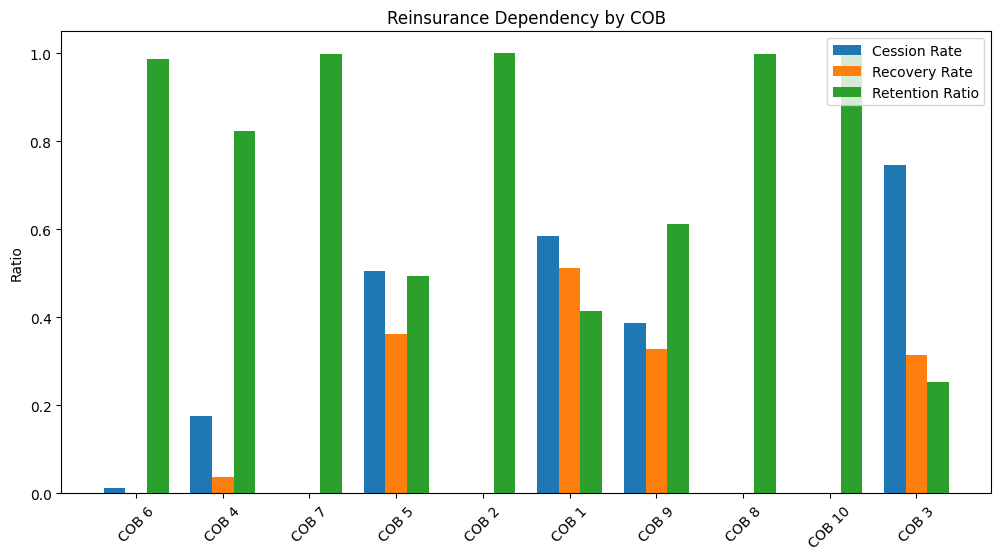

In [ ]:
plt.figure(figsize=(12,6))
x = np.arange(len(reinsurance_df))
width = 0.25

plt.bar(
    x - width,
    reinsurance_df['CESSION_RATE'],
    width,
    label='Cession Rate')

plt.bar(
    x,
    reinsurance_df['RECOVERY_RATE'],
    width,
    label='Recovery Rate')

plt.bar(
    x + width,
    reinsurance_df['RETENTION_RATIO'],
    width,
    label='Retention Ratio')

plt.xticks(
    x,
    reinsurance_df['COB'],
    rotation=45)

plt.ylabel('Ratio')
plt.title('Reinsurance Dependency by COB')
plt.legend()
plt.show()

# **Trend Analysis**

   YEAR       GWP_IDR       RWP_IDR   NET_PREMIUM  GROSS_INCURRED  \
0  2021  8.555708e+11  1.877813e+11  6.677896e+11    5.909887e+11   
1  2022  8.141327e+11  1.806130e+11  6.335197e+11    3.167121e+11   
2  2023  8.410160e+11  1.782039e+11  6.628120e+11    2.162093e+11   
3  2024           NaN           NaN           NaN    1.056164e+11   
4  2025           NaN           NaN           NaN    9.209372e+09   
5  2026           NaN           NaN           NaN    1.457094e+08   

   NET_INCURRED  GROSS_LOSS_RATIO  NET_LOSS_RATIO  
0  5.609290e+11          0.690754        0.839979  
1  2.932850e+11          0.389018        0.462945  
2  1.995775e+11          0.257081        0.301107  
3  8.746893e+10               NaN             NaN  
4  8.347047e+09               NaN             NaN  
5  1.457094e+08               NaN             NaN  


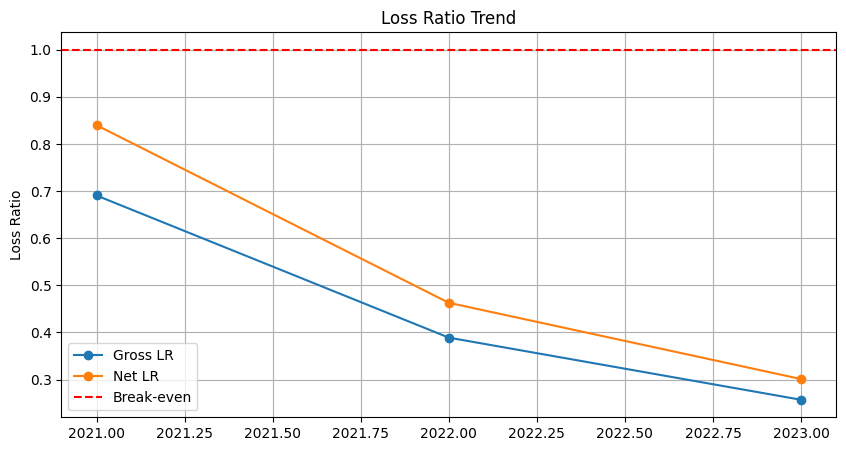

In [ ]:
# =========================================================
# STEP 7 - TREND ANALYSIS
# =========================================================

# ==========================================
# CREATE CLAIM METRICS
# ==========================================

df_claim['GROSS_INCURRED'] = (
    df_claim['GRS_ST_IDR']
    +
    df_claim['GRS_OS_IDR']
)

df_claim['RI_RECOVERY'] = (
    df_claim['RI_ST_IDR']
    +
    df_claim['RI_OS_IDR']
)

df_claim['NET_INCURRED'] = (
    df_claim['GROSS_INCURRED']
    -
    df_claim['RI_RECOVERY']
)

# ==========================================
# PREMIUM TREND
# ==========================================

premium_trend = (
    df_prem
    .groupby('UW_YEAR')
    .agg({
        'GWP_IDR':'sum',
        'RWP_IDR':'sum'
    })
    .reset_index()
)

premium_trend['NET_PREMIUM'] = (
    premium_trend['GWP_IDR']
    -
    premium_trend['RWP_IDR']
)

# ==========================================
# CLAIM TREND
# ==========================================

claim_trend = (
    df_claim
    .groupby('CLM_YEAR')
    .agg({
        'GROSS_INCURRED':'sum',
        'NET_INCURRED':'sum'
    })
    .reset_index()
)

# Rename year column
claim_trend.rename(columns={
    'CLM_YEAR':'YEAR'
}, inplace=True)

premium_trend.rename(columns={
    'UW_YEAR':'YEAR'
}, inplace=True)

# ==========================================
# MERGE
# ==========================================

trend_df = pd.merge(
    premium_trend,
    claim_trend,
    on='YEAR',
    how='outer'
)

trend_df = trend_df.sort_values('YEAR')

# ==========================================
# LOSS RATIO
# ==========================================

trend_df['GROSS_LOSS_RATIO'] = np.where(
    trend_df['GWP_IDR'] != 0,
    trend_df['GROSS_INCURRED']
    /
    trend_df['GWP_IDR'],
    0
)

trend_df['NET_LOSS_RATIO'] = np.where(
    trend_df['NET_PREMIUM'] != 0,
    trend_df['NET_INCURRED']
    /
    trend_df['NET_PREMIUM'],
    0
)

print(trend_df)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    trend_df['YEAR'],
    trend_df['GROSS_LOSS_RATIO'],
    marker='o',
    label='Gross LR'
)

plt.plot(
    trend_df['YEAR'],
    trend_df['NET_LOSS_RATIO'],
    marker='o',
    label='Net LR'
)

plt.axhline(
    1,
    color='red',
    linestyle='--',
    label='Break-even'
)

plt.title('Loss Ratio Trend')

plt.ylabel('Loss Ratio')

plt.legend()

plt.grid(True)

plt.show()

# **Drill Down Analysis**

In [ ]:
# =========================================================
# STEP 8 - DRILL DOWN ANALYSIS
# =========================================================

def drill_down_analysis(
    claim_df,
    prem_df,
    segment_cols
):

    if isinstance(segment_cols, str):
        segment_cols = [segment_cols]

    # ==========================================
    # CLAIM METRICS
    # ==========================================

    claim_df = claim_df.copy()
    prem_df = prem_df.copy() # Make a copy of prem_df too to avoid side effects

    # Ensure all segment columns are in claim_df before merging with prem_df for numericals
    for col in segment_cols:
        if col not in claim_df.columns and col in prem_df.columns:
            # Create a temporary DataFrame with POLICY_NO and the missing segment col
            # and merge it into claim_df
            temp_map_df = prem_df[['POLICY_NO', col]].drop_duplicates()
            claim_df = pd.merge(claim_df, temp_map_df, on='POLICY_NO', how='left')

    claim_df['GROSS_INCURRED'] = (
        claim_df['GRS_ST_IDR']
        +
        claim_df['GRS_OS_IDR']
    )

    claim_df['RI_RECOVERY'] = (
        claim_df['RI_ST_IDR']
        +
        claim_df['RI_OS_IDR']
    )

    claim_df['NET_INCURRED'] = (
        claim_df['GROSS_INCURRED']
        -
        claim_df['RI_RECOVERY']
    )

    # ==========================================
    # MERGE CLAIM + PREMIUM (for GWP_IDR, SUM_INSURED)
    # ==========================================

    # Select only POLICY_NO and value columns from prem_df to avoid duplicate segment columns
    prem_value_cols = ['POLICY_NO', 'GWP_IDR', 'SUM_INSURED']
    prem_df_filtered = prem_df[prem_value_cols].drop_duplicates(subset=['POLICY_NO']).copy()

    merged = pd.merge(
        claim_df, # claim_df now contains all necessary segment_cols
        prem_df_filtered, # Merge with the filtered premium DataFrame
        on='POLICY_NO',
        how='left'
    )

    # ==========================================d
    # AGGREGATION
    # ==========================================

    drill_df = (
        merged
        .groupby(segment_cols)
        .agg({
            'GROSS_INCURRED':'sum',
            'NET_INCURRED':'sum',
            'GWP_IDR':'sum',
            'SUM_INSURED':'sum',
            'CLM_REF':'count'
        })
        .reset_index()
    )

    # ==========================================d
    # LOSS RATIO
    # ==========================================

    drill_df['LOSS_RATIO'] = np.where(
        drill_df['GWP_IDR'] != 0,
        drill_df['GROSS_INCURRED']
        /
        drill_df['GWP_IDR'],
        0
    )

    # ==========================================d
    # CLAIM SEVERITY
    # ==========================================

    drill_df['CLAIM_SEVERITY'] = np.where(
        drill_df['CLM_REF'] != 0,
        drill_df['GROSS_INCURRED']
        /
        drill_df['CLM_REF'],
        0
    )

    # ==========================================d
    # SORT
    # ==========================================

    drill_df = (
        drill_df
        .sort_values(
            by='LOSS_RATIO',
            ascending=False
        )
    )

    print(drill_df.head(20))

    return drill_df

**COB x Branch**

In [ ]:
drill_1 = drill_down_analysis(
    df_claim,
    df_prem,
    ['COB', 'BRANCH_']
)

      COB   BRANCH_  GROSS_INCURRED  NET_INCURRED       GWP_IDR   SUM_INSURED  \
59  COB 9  BRANCH A    2.181830e+13  2.101467e+13  1.455024e+10  8.382806e+12   
38  COB 6  BRANCH K    3.688163e+14  3.688163e+14  2.796038e+11  4.888456e+13   
36  COB 6  BRANCH C    4.461738e+10  4.461738e+10  1.744486e+08  1.789613e+13   
23  COB 4  BRANCH C    1.489809e+11  1.489809e+11  9.429917e+08  1.045516e+12   
37  COB 6  BRANCH J    1.687453e+12  1.675417e+12  1.214970e+10  8.992159e+15   
26  COB 4  BRANCH J    2.470664e+13  2.470530e+13  1.803044e+11  2.305223e+14   
24  COB 4  BRANCH D    8.617354e+11  8.596237e+11  6.721848e+09  2.618500e+13   
35  COB 6  BRANCH B    1.174266e+10  1.174266e+10  1.115607e+08  1.188997e+13   
65  COB 9  BRANCH G    1.339523e+10  1.072438e+10  1.390198e+08  8.608104e+10   
29  COB 5  BRANCH B    2.756144e+09  2.756144e+09  3.000000e+07  3.750000e+09   
51  COB 8  BRANCH C    7.481829e+13  7.481829e+13  9.033707e+11  2.560157e+14   
34  COB 6  BRANCH A    1.725

**Semua Segmen**

In [ ]:
drill_3 = drill_down_analysis(
    df_claim,
    df_prem,
    [
        'COB',
        'BRANCH_',
        'CHANNEL_',
        'PRODUCT_NAME'
    ]
)

       COB   BRANCH_   CHANNEL_ PRODUCT_NAME  GROSS_INCURRED  NET_INCURRED  \
179  COB 9  BRANCH A  CHANNEL D  PRODUCT0124    5.914791e+09  5.766921e+09   
157  COB 8  BRANCH B  CHANNEL D  PRODUCT1004    1.937779e+10  1.937779e+10   
143  COB 7  BRANCH J  CHANNEL D  PRODUCT0223    7.822170e+08  7.822170e+08   
33   COB 2  BRANCH K  CHANNEL B  PRODUCT1302    3.901500e+09  3.901500e+09   
77   COB 6  BRANCH J  CHANNEL D  PRODUCT1270    7.670700e+09  7.670700e+09   
54   COB 4  BRANCH C  CHANNEL E  PRODUCT0311    3.307315e+08  3.307315e+08   
166  COB 8  BRANCH F  CHANNEL D  PRODUCT1004    4.441456e+09  4.441456e+09   
167  COB 8  BRANCH G  CHANNEL D  PRODUCT1004    2.370886e+09  2.370886e+09   
177  COB 9  BRANCH A  CHANNEL D  PRODUCT0101    5.760017e+09  4.522982e+09   
229  COB 9  BRANCH G  CHANNEL E  PRODUCT0110    1.569611e+09  1.224296e+09   
83   COB 6  BRANCH K  CHANNEL B  PRODUCT1217    3.664564e+11  3.664564e+11   
100  COB 7  BRANCH B  CHANNEL D  PRODUCT0222    6.266700e+08  6.

# **Risk Profile Mapping**


===== REINSURANCE ANALYSIS BY COB =====
      COB       GWP_IDR       RWP_IDR   NET_PREMIUM  GROSS_INCURRED  \
0   COB 6  4.206605e+11  5.476914e+09  4.151836e+11    3.840697e+11   
1   COB 4  3.192075e+11  5.620782e+10  2.629997e+11    2.913542e+11   
2   COB 7  3.429804e+11  2.834829e+08  3.426969e+11    2.981591e+11   
3   COB 5  1.510009e+11  7.631139e+10  7.468951e+10    5.802572e+10   
4   COB 2  2.094564e+10  5.180234e+04  2.094558e+10    5.434200e+09   
5   COB 1  1.196189e+11  6.993509e+10  4.968382e+10    2.616669e+10   
6   COB 9  7.624109e+11  2.954189e+11  4.669920e+11    1.306912e+11   
7   COB 8  2.515343e+11  4.482585e+07  2.514895e+11    3.782976e+10   
8  COB 10  6.489250e+10  0.000000e+00  6.489250e+10    5.870562e+09   
9   COB 3  5.746793e+10  4.291977e+10  1.454815e+10    1.280414e+09   

    RI_RECOVERY  NET_INCURRED  GROSS_LOSS_RATIO  NET_LOSS_RATIO  CESSION_RATE  \
0  4.310916e+08  3.836386e+11          0.913016        0.924022      0.013020   
1  1.113620e+10

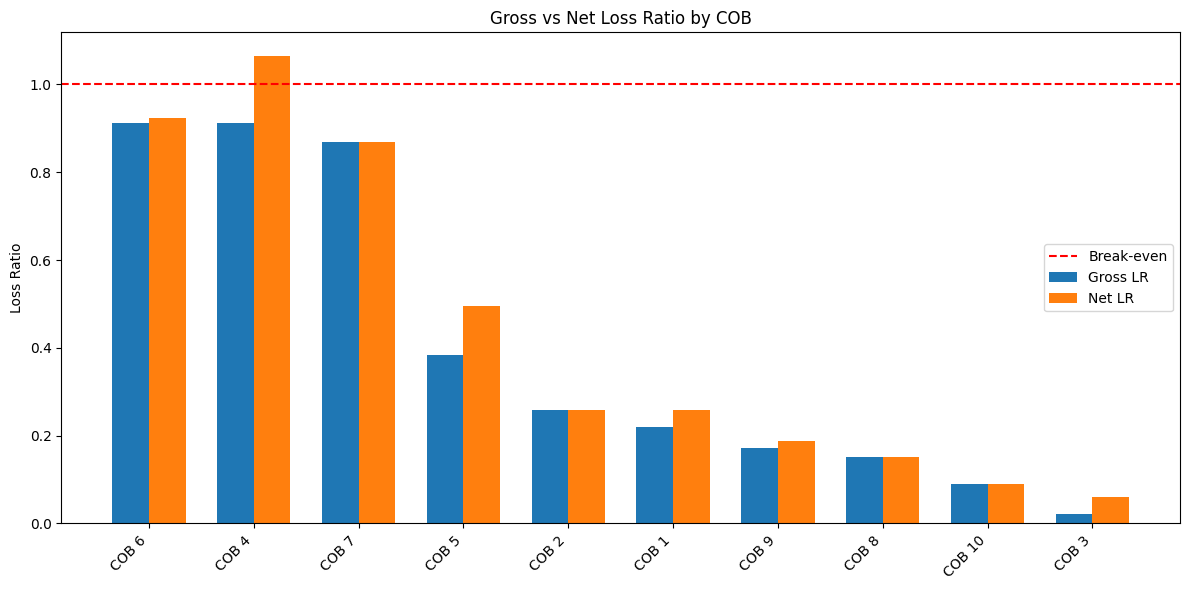

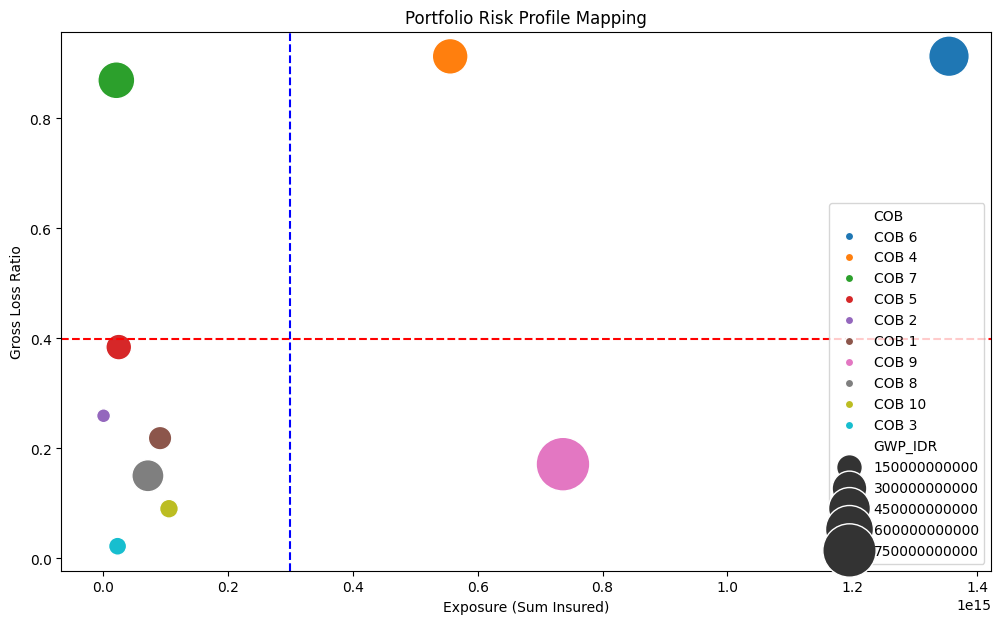

In [ ]:
# =========================================================
# STEP 9 - RISK PROFILE MAPPING
# =========================================================

# Call the reinsurance analysis function for COB only to get relevant metrics
cob_analysis = calculate_reinsurance_analysis(
    df_claim,
    df_prem,
    'COB'
)

risk_map = (
    cob_analysis.copy()
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=risk_map,
    x='SUM_INSURED',
    y='GROSS_LOSS_RATIO',
    size='GWP_IDR',
    hue='COB',
    sizes=(100,1500)
)

# Average line
plt.axhline(
    risk_map['GROSS_LOSS_RATIO'].mean(),
    linestyle='--',
    color='red'
)

plt.axvline(
    risk_map['SUM_INSURED'].mean(),
    linestyle='--',
    color='blue'
)

plt.title('Portfolio Risk Profile Mapping')

plt.xlabel('Exposure (Sum Insured)')
plt.ylabel('Gross Loss Ratio')

plt.show()